In [2]:
# ============================================================
# Dataset: Uber Ride Analytics Dashboard
# Source  : Kaggle — https://www.kaggle.com/datasets/
#           yashdevladdha/uber-ride-analytics-dashboard
# Author  : Yash Devladdha
# License : CC BY-SA 4.0
# Note    : This project is for educational/portfolio purposes only.
# ============================================================

# ── Cell 1: Imports & Display Settings ──────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option("display.max_columns", 25)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

print("Environment ready.")
print(f"pandas version: {pd.__version__}")

Environment ready.
pandas version: 2.3.3


In [3]:
#  ── Cell 2: Load Raw Data ───────────────────────────────────
FILE_PATH = "ncr_ride_bookings.csv"   # ← update path if needed

try:
    df = pd.read_csv(
        FILE_PATH,
        quotechar='"',
        escapechar="\\",
        on_bad_lines="warn",
        low_memory=False,
    )
    print(f"Data loaded successfully — shape: {df.shape}")
    display(df.head(3))
except FileNotFoundError:
    raise FileNotFoundError(
        f"File not found: '{FILE_PATH}'. "
        "Please update FILE_PATH to the correct location."
    )

Data loaded successfully — shape: (150000, 21)


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.90,14.00,NaN,NaN,NaN,NaN,1.00,Vehicle Breakdown,237.00,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.40,25.80,NaN,NaN,NaN,NaN,NaN,NaN,627.00,13.58,4.90,4.90,Debit Card


In [4]:
#  ── Cell 3: Data Quality Overview ───────────────────────────
print("=== Basic Info ===")
df.info()

# Missing-value summary
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print("\n=== Missing Values (descending) ===")
display(missing_df[missing_df["Missing Count"] > 0])

# Descriptive statistics (numeric columns only)
print("\n=== Descriptive Statistics ===")
display(df.describe().round(2))

# Unique-value counts for categorical columns
print("\n=== Categorical Columns — Unique Values ===")
for col in df.select_dtypes(include="object").columns:
    print(f"  {col:<35}: {df[col].nunique()} unique values")

=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancellin

,Missing Count,Missing %
Incomplete Rides Reason,141000,94.00
Incomplete Rides,141000,94.00
Cancelled Rides by Customer,139500,93.00
Reason for cancelling by Customer,139500,93.00
Driver Cancellation Reason,123000,82.00
Cancelled Rides by Driver,123000,82.00
Customer Rating,57000,38.00
Driver Ratings,57000,38.00
Ride Distance,48000,32.00
Booking Value,48000,32.00



=== Descriptive Statistics ===


,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.00,102000.00,10500.00,27000.00,9000.00,102000.00,102000.00,93000.00,93000.00
mean,8.46,29.15,1.00,1.00,1.00,508.30,24.64,4.23,4.40
std,3.77,8.90,0.00,0.00,0.00,395.81,14.00,0.44,0.44
min,2.00,10.00,1.00,1.00,1.00,50.00,1.00,3.00,3.00
25%,5.30,21.60,1.00,1.00,1.00,234.00,12.46,4.10,4.20
50%,8.30,28.80,1.00,1.00,1.00,414.00,23.72,4.30,4.50
75%,11.30,36.80,1.00,1.00,1.00,689.00,36.82,4.60,4.80
max,20.00,45.00,1.00,1.00,1.00,4277.00,50.00,5.00,5.00



=== Categorical Columns — Unique Values ===
  Date                               : 365 unique values
  Time                               : 62910 unique values
  Booking ID                         : 148767 unique values
  Booking Status                     : 5 unique values
  Customer ID                        : 148788 unique values
  Vehicle Type                       : 7 unique values
  Pickup Location                    : 176 unique values
  Drop Location                      : 176 unique values
  Reason for cancelling by Customer  : 5 unique values
  Driver Cancellation Reason         : 4 unique values
  Incomplete Rides Reason            : 3 unique values
  Payment Method                     : 5 unique values


In [5]:
#  ── Cell 4: Data Cleaning ───────────────────────────────────

# 4.1  Strip stray quotes from ID columns
for col in ["Booking ID", "Customer ID"]:
    if col in df.columns:
        df[col] = df[col].str.strip('"').str.strip()

# 4.2  Combine Date + Time into a single datetime column
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce",
)

# Warn if any rows failed to parse
n_bad = df["Datetime"].isna().sum()
if n_bad:
    print(f"⚠  {n_bad} rows failed datetime parsing — inspect below:")
    display(df[df["Datetime"].isna()][["Date", "Time"]].head())

# 4.3  Extract temporal features
df["Hour"]       = df["Datetime"].dt.hour
df["Weekday"]    = df["Datetime"].dt.weekday   # 0 = Monday, 6 = Sunday
df["Is_Weekend"] = df["Weekday"].isin([5, 6]).astype(int)
df["Month"]      = df["Datetime"].dt.month
df["Date_only"]  = df["Datetime"].dt.date

# 4.4  Coerce numeric columns (handles edge-case strings)
NUM_COLS = [
    "Avg VTAT", "Avg CTAT", "Booking Value",
    "Ride Distance", "Driver Ratings", "Customer Rating",
]
for col in NUM_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 4.5  Derive cancellation category from Booking Status
STATUS_MAP = {
    "Cancelled by Customer": "Customer Cancelled",
    "Cancelled by Driver":   "Driver Cancelled",
    "No Driver Found":       "No Driver Found",
    "Incomplete":            "Incomplete",
}

def classify_status(status: str) -> str:
    for key, label in STATUS_MAP.items():
        if key in status:
            return label
    return "Completed"

df["Cancel_Type"] = df["Booking Status"].apply(classify_status)

# 4.6  Bin ride distances for segment-level analysis
if "Ride Distance" in df.columns:
    bins   = [0, 5, 10, 20, 50, np.inf]
    labels = ["0-5 km", "5-10 km", "10-20 km", "20-50 km", "50+ km"]
    df["Distance_Bin"] = pd.cut(
        df["Ride Distance"], bins=bins, labels=labels, right=False
    )

In [6]:
# ── Cell 5: Handle Missing Values ───────────────────────────
# Strategy A — numeric columns: fill with median (robust to outliers)
for col in NUM_COLS:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Strategy B — text/reason columns: fill with "Unknown"
TEXT_COLS = [
    "Reason for cancelling by Customer",
    "Driver Cancellation Reason",
    "Incomplete Rides Reason",
]
for col in TEXT_COLS:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# Remaining missing values after imputation
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
print("Remaining missing values after imputation:")
display(remaining if not remaining.empty else pd.Series(dtype=int, name="(none)"))

Remaining missing values after imputation:


Cancelled Rides by Customer    139500
Cancelled Rides by Driver      123000
Incomplete Rides               141000
Payment Method                  48000
Distance_Bin                    48000
dtype: int64

In [7]:
# ── Cell 6: Export Cleaned Dataset ──────────────────────────
KEEP_COLS = [
    "Datetime", "Hour", "Weekday", "Is_Weekend", "Month", "Date_only",
    "Booking ID", "Customer ID", "Booking Status", "Cancel_Type",
    "Vehicle Type", "Pickup Location", "Drop Location",
    "Avg VTAT", "Avg CTAT", "Ride Distance", "Distance_Bin",
    "Booking Value", "Driver Ratings", "Customer Rating",
    "Payment Method",
    "Reason for cancelling by Customer",
    "Driver Cancellation Reason",
    "Incomplete Rides Reason",
]

df_clean = df[[c for c in KEEP_COLS if c in df.columns]].copy()

CLEANED_FILE = "cleaned_ncr_rides.csv"
df_clean.to_csv(CLEANED_FILE, index=False, encoding="utf-8")
print(f"Cleaned data saved → {os.path.abspath(CLEANED_FILE)}")
print(f"Shape: {df_clean.shape}")

Cleaned data saved → C:\Users\85255\Desktop\HKU\hku_yr4\Internship\ncr-ride-booking-analysis\cleaned_ncr_rides.csv
Shape: (150000, 24)


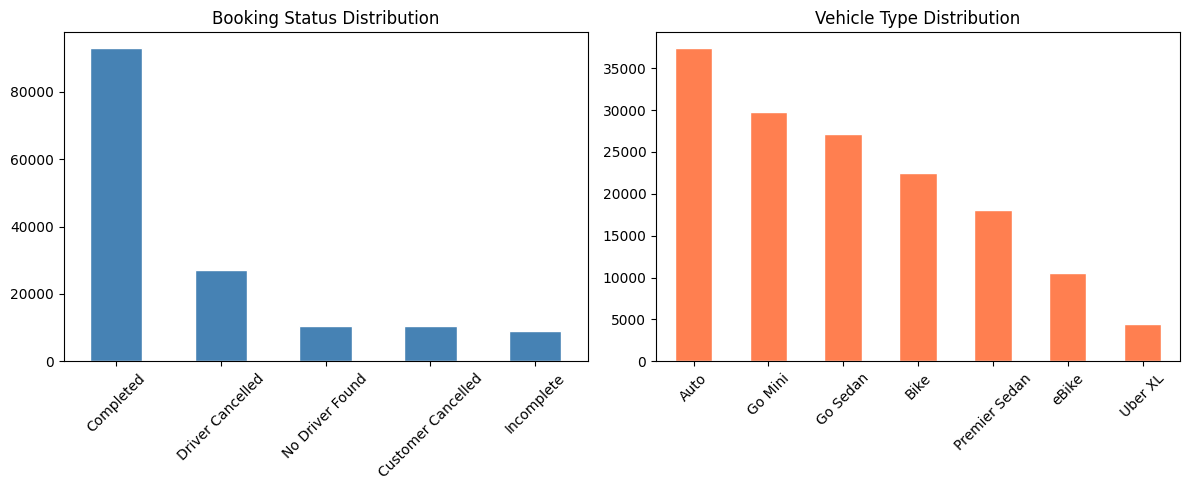

Plot saved to 01_distributions.png


In [8]:
# ── Cell 7: Quick Validation Plots ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_clean["Cancel_Type"].value_counts().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Booking Status Distribution")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

df_clean["Vehicle Type"].value_counts().plot(
    kind="bar", ax=axes[1], color="coral", edgecolor="white"
)
axes[1].set_title("Vehicle Type Distribution")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("01_distributions.png", dpi=150)   # save for portfolio / website
plt.show()
print("Plot saved to 01_distributions.png")